In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import torch
from torch.utils.data import DataLoader
from model import UNet
from utils_noise import *
import pickle
import copy
device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps


#### Parameters

In [32]:
store_path = "/Users/aj/Desktop/work/PostDoc_UMCG/work/analysis/EDX_Project/PreHyperspectralEDX/preprocessing_basic/tmp/aligned_hsi/"
patch_size = (128,128)
n_input_frames = 10
n_patches = 16
batch_size = 4
n_epochs = 1000
lr = 1e-3
bands = [24,25,28]

In [33]:
# Dataset and DataLoader
dataset = HyperspectralPatchDataset(store_path, patch_size=patch_size, bands=bands, n_input_frames=n_input_frames, n_patches=n_patches)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model
sample_input, _ = dataset[0]
in_ch = sample_input.shape[0]
model = UNet(in_ch, in_ch).to(device)

# Optimizer and Loss
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()

# Training loop
for epoch in range(n_epochs):
    total_loss = 0
    for i, (x, y) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if np.mod(epoch,100)==0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(loader):.6f}")

# Save model
torch.save(model.state_dict(), "noise2noise_hyper.pth")

Epoch 1/1000, Loss: 0.002487
Epoch 101/1000, Loss: 0.001404
Epoch 201/1000, Loss: 0.001243
Epoch 301/1000, Loss: 0.001377
Epoch 401/1000, Loss: 0.001210
Epoch 501/1000, Loss: 0.001345
Epoch 601/1000, Loss: 0.001264
Epoch 701/1000, Loss: 0.001243
Epoch 801/1000, Loss: 0.001440
Epoch 901/1000, Loss: 0.001241


## Test

In [6]:
# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile = pickle.load(file)

In [35]:
# Example setup
#patch_size = (8, 8)  # same as training

# Load model
in_ch = len(bands) #tile.EDX.shape[2]
model = UNet(in_ch, in_ch).to(device)
model.load_state_dict(torch.load("noise2noise_hyper.pth", map_location=device))
model.eval()

# Pad image if needed to be divisible by patch size
H, W, B = tile.EDX.shape
h_t, w_t = patch_size

pad_h = (h_t - H % h_t) % h_t
pad_w = (w_t - W % w_t) % w_t

if bands is None:
    padded = np.pad(tile.EDX, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect') 
else:
    padded = np.pad(tile.EDX[:,:,bands], ((0,pad_h),(0,pad_w),(0,0)), mode='reflect') 
    
H_p, W_p, _ = padded.shape

# Prepare output array
output = np.zeros_like(padded, dtype=np.float32)

# Sliding over patches
for i in range(0, H_p, h_t):
    for j in range(0, W_p, w_t):
        patch = padded[i:i+h_t, j:j+w_t, :] 
        patch_tensor = torch.from_numpy(patch).float().permute(2,0,1).unsqueeze(0).to(device)  # (1, b, h, w)
        
        with torch.no_grad():
            pred = model(patch_tensor)
        
        pred_np = pred.squeeze(0).permute(1,2,0).cpu().numpy()  # back to (h, w, b)
        output[i:i+h_t, j:j+w_t, :] = pred_np

# Remove padding
if pad_h > 0: output = output[:H, :, :]
if pad_w > 0: output = output[:, :W, :]

print("Reconstructed output shape:", output.shape)  # should be (2048, 2048, 250)



Reconstructed output shape: (2048, 2048, 3)


### Seamless reconstruction

In [34]:
# Pad image if needed to be divisible by patch size
h_t, w_t = patch_size

pad_h = (h_t - H % h_t) % h_t
pad_w = (w_t - W % w_t) % w_t

if bands is None:
    padded = np.pad(tile.EDX, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect') 
else:
    padded = np.pad(tile.EDX[:,:,bands], ((0,pad_h),(0,pad_w),(0,0)), mode='reflect') 


# ==== PARAMETERS ====
overlap = 16  # amount of overlap for seamless blending
patch_h, patch_w = patch_size

# ==== PREPARE INPUT ====
# (H_p, W_p, B) → (1, B, H_p, W_p)
img = torch.from_numpy(padded).float().permute(2,0,1).unsqueeze(0).to(device)
B = img.shape[1]
H_p, W_p = img.shape[2], img.shape[3]

# ==== CREATE UNFOLD WITH OVERLAP ====
kernel = (patch_h, patch_w)
stride = (patch_h - overlap, patch_w - overlap)

unfold = torch.nn.Unfold(kernel_size=kernel, stride=stride)
patches = unfold(img)  # (1, B*h*w, N)

# reshape to (N, B, h, w)
N = patches.shape[-1]
patches = patches.view(1, B, patch_h, patch_w, N)
patches = patches.permute(4,1,2,3,0).squeeze(-1)  # (N, B, h, w)

# ==== CREATE WEIGHT WINDOW (cosine/Hann) ====
wx = torch.hann_window(patch_w, periodic=False).to(device)
wy = torch.hann_window(patch_h, periodic=False).to(device)
weight2d = torch.outer(wy, wx).unsqueeze(0).unsqueeze(0)  # (1,1,h,w)

# expand to all channels
weight = weight2d.expand(1, B, patch_h, patch_w)  # (1,B,h,w)

# ==== MODEL INFERENCE WITH WEIGHTING ====
with torch.no_grad():
    preds = model(patches)  # (N, B, h, w)
    preds = preds * weight  # apply smooth window

# ==== FOLD BACK (numerator) ====
preds_flat = preds.view(N, -1).transpose(0,1).unsqueeze(0)  # (1, B*h*w, N)

fold = torch.nn.Fold(output_size=(H_p, W_p),
                     kernel_size=kernel,
                     stride=stride)

numerator = fold(preds_flat)  # (1, B, H_p, W_p)

# ==== FOLD WEIGHTS (denominator) ====
w_flat = weight.view(1, -1, 1).repeat(1, 1, N)  # (1, B*h*w, N)
denominator = fold(w_flat)  # (1, B, H_p, W_p)

# ==== FINAL SEAMLESS RECONSTRUCTION ====
reconstructed = numerator / (denominator + 1e-8)
output = reconstructed.squeeze(0).permute(1,2,0).cpu().numpy()

# remove padding
if pad_h > 0: output = output[:H, :, :]
if pad_w > 0: output = output[:, :W, :]


print("Reconstructed output shape:", output.shape)  # should be (2048, 2048, 250)

RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [36]:
# create a new denoised tile object
tile_denoised = copy.deepcopy(tile)
tile_denoised.EDX[:,:,bands] = output

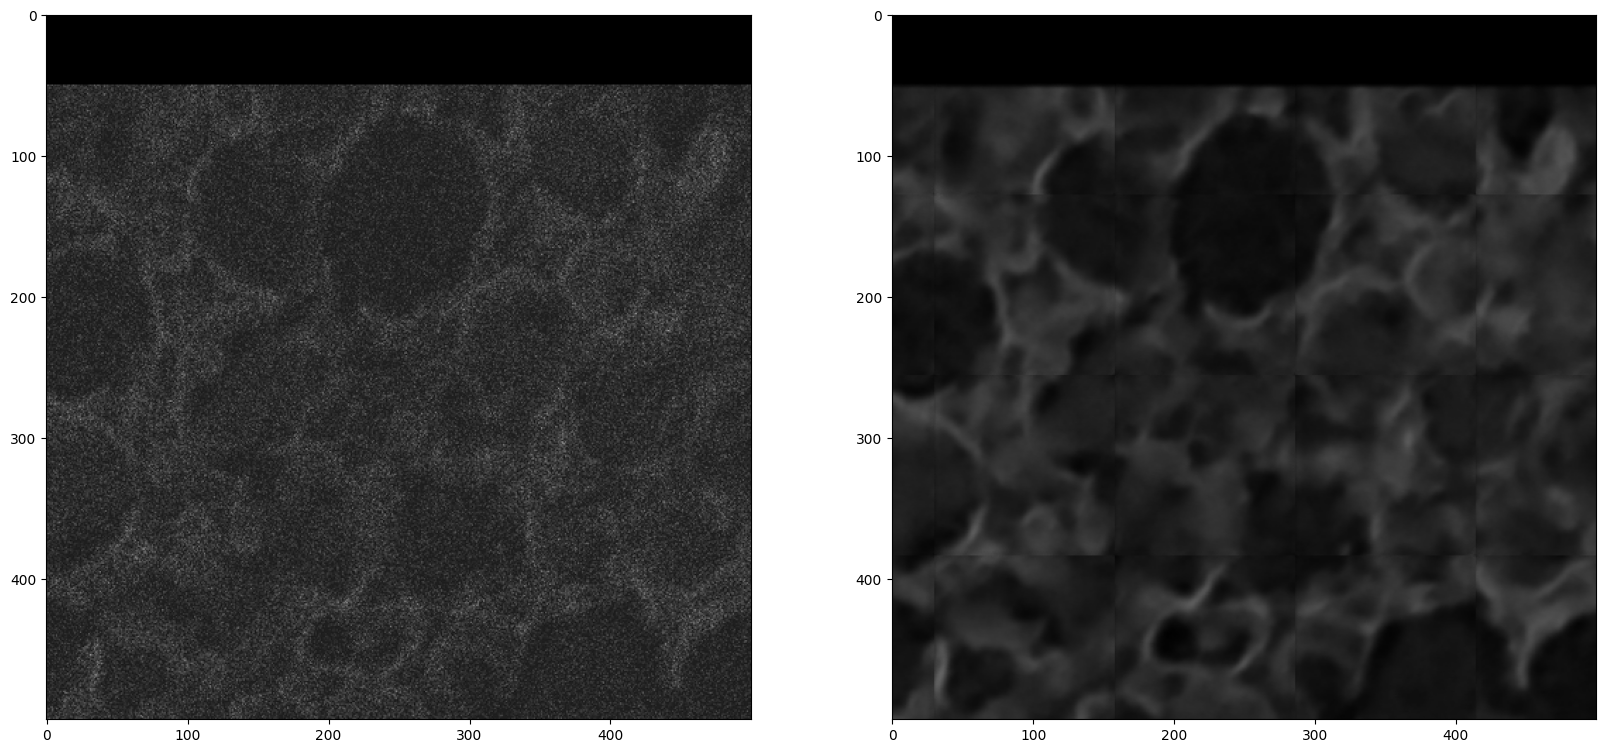

In [43]:
f, ax = plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(tile.FalseColor(bands=[24,24,24])[0:500,1250:1750])
ax[1].imshow(tile_denoised.FalseColor(bands=[24,24,24])[0:500,1250:1750]) 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.096796304..1.1093888].


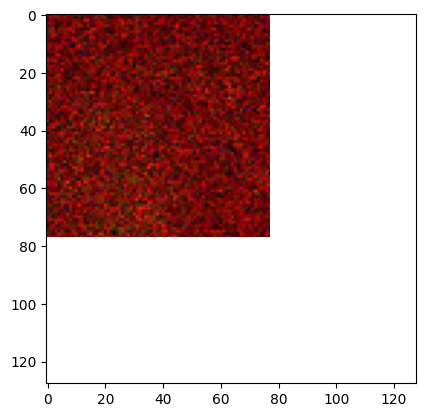

In [57]:
plt.imshow(patch)